In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def hamiltonian_matrix(delta_x,potential_values):
  potential_values = np.asarray(potential_values,dtype=float)
  if delta_x <=0:
    raise ValueError("detla_x must be greater than 0")
  if potential_values.ndim != 1:
    raise ValueError("potential_values must be a one-dimensional array.")
  if potential_values.size == 0:
    raise ValueError("potential_values cannot be empty.")

  interior_points = len(potential_values)

  main_diag = 1/(delta_x**2) + potential_values
  off_diag = np.full(interior_points-1,-1/(2*(delta_x**2)))

  hamiltonian = (np.diag(main_diag) + np.diag(off_diag,k=1) + np.diag(off_diag,k=-1))

  return hamiltonian

In [3]:
def solve_and_plot(xi,xf,interior_points,state_index,potential_values):
  delta_x = (xf - xi)/(interior_points + 1)
  interior_grid = (xi + delta_x*np.arange(1,interior_points+1))

  potential_values = np.asarray(potential_values,dtype=float)

  if state_index < 0 or state_index >= interior_points:
    raise ValueError("state_index must lie between 0 and interior_points - 1.")

  H = hamiltonian_matrix(delta_x,potential_values)

  eigenvalues,eigenvectors = np.linalg.eigh(H)

  phi_interior   = eigenvectors[:,state_index]
  energy_value   = eigenvalues[state_index]
  phi            = np.concatenate(([0.0],phi_interior,[0.0]))
  normalization  = np.sum(np.abs(phi)**2)*delta_x
  phi_normalized = phi/np.sqrt(normalization)
  full_grid      = np.concatenate(([xi],interior_grid,[xf]))
  quantum_number = state_index + 1
  check = np.sum(np.abs(phi_normalized)**2) * delta_x
  print("Normalization =", check)

  plt.plot(full_grid,phi_normalized,label=f"State {quantum_number}")
  plt.axhline(0,linewidth=0.8,linestyle="--")
  plt.xlabel("Dimensionless position, x")
  plt.ylabel(r"Eigenvector $\phi(x)$")
  plt.title(f"Eigenvalue n = {quantum_number}, "f"Energy = {energy_value:.6f}")
  plt.grid(alpha=0.3)
  plt.legend()
  plt.show()

  return full_grid,phi,energy_value

**Infinite Potential Well**

Normalization = 1.0


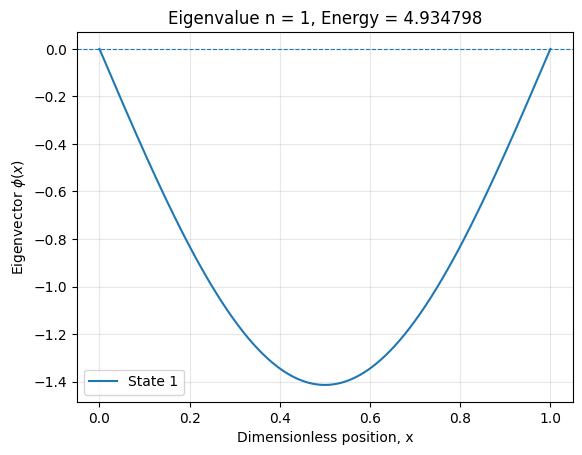

In [45]:
interior_points = 1000
potential_values = np.zeros(interior_points)

x, phi, energy = solve_and_plot(
    xi=0,
    xf=1,
    interior_points=interior_points,
    state_index=0,
    potential_values=potential_values
)

**Comparing energy values with n**

Normalization = 1.0


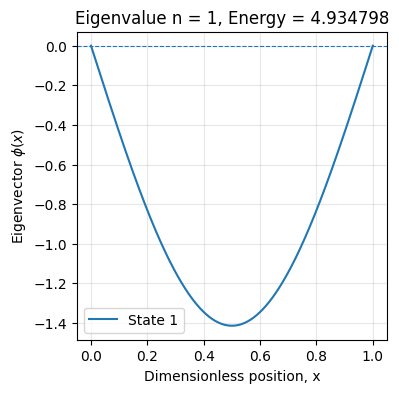

Normalization = 0.9999999999999999


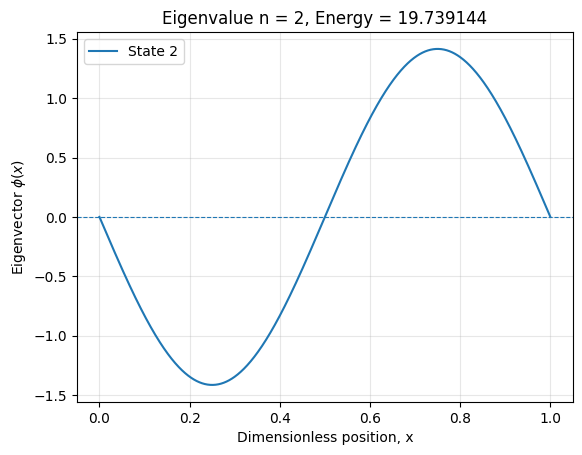

Normalization = 1.0000000000000002


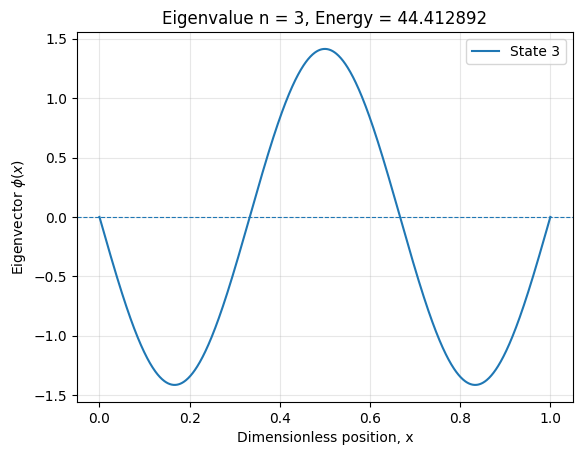

Normalization = 1.0


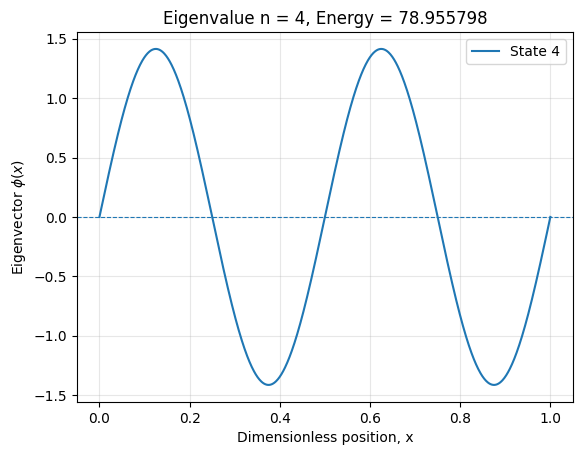

Normalization = 0.9999999999999998


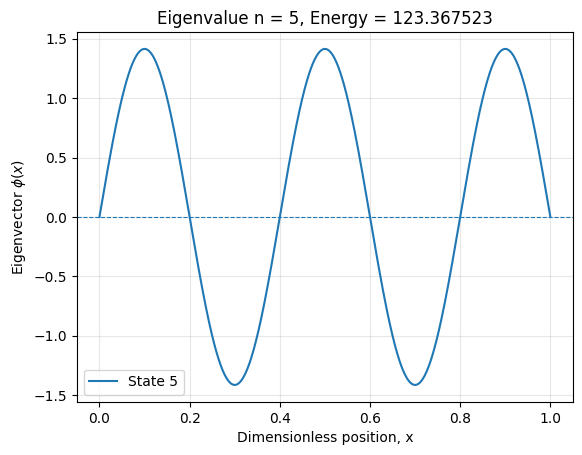

In [4]:
interior_points = 1000
potential_values = np.zeros(interior_points)
states = [0,1,2,3,4]
plt.figure(figsize= (4,4))
for state_index in states:
    x, phi, energy = solve_and_plot(xi=0,xf=1,interior_points=interior_points,state_index=state_index,potential_values=potential_values)

**Probability Distribution Curve and Area**

In [5]:
def probability_distributuion(xi,xf,interior_points,state_index,potential_values):
  delta_x = (xf - xi)/(interior_points + 1)
  interior_grid = (xi + delta_x*np.arange(1,interior_points+1))

  potential_values = np.asarray(potential_values,dtype=float)

  if state_index < 0 or state_index >= interior_points:
    raise ValueError("state_index must lie between 0 and interior_points - 1.")

  H = hamiltonian_matrix(delta_x,potential_values)

  eigenvalues,eigenvectors = np.linalg.eigh(H)

  phi_interior   = eigenvectors[:,state_index]
  energy_value   = eigenvalues[state_index]
  phi            = np.concatenate(([0.0],phi_interior,[0.0]))
  normalization  = np.sum(np.abs(phi)**2)*delta_x
  phi_normalized = phi/np.sqrt(normalization)
  full_grid      = np.concatenate(([xi],interior_grid,[xf]))
  quantum_number = state_index + 1
  check = np.sum(np.abs(phi_normalized)**2) * delta_x
  probability_curve = np.abs(phi_normalized)**2
  print("Normalization =", check)

  #Calculating area under the graph
  area = delta_x*np.sum(probability_curve[0]/2 + probability_curve[-1]/2 + np.sum(probability_curve[1:-1]))
  print(f"Area under curve : {area}")

  plt.plot(full_grid,probability_curve,label=f"State {quantum_number}")
  plt.axhline(0,linewidth=0.8,linestyle="--")
  plt.xlabel("Dimensionless position, x")
  plt.ylabel(r"Eigenvector $\phi(x)$")
  plt.title(f"Eigenvalue n = {quantum_number}, "f"Energy = {energy_value:.6f}")
  plt.grid(alpha=0.3)
  plt.legend()
  plt.show()
  
  return full_grid,phi,energy_value

Normalization = 1.0
Area under curve : 1.0


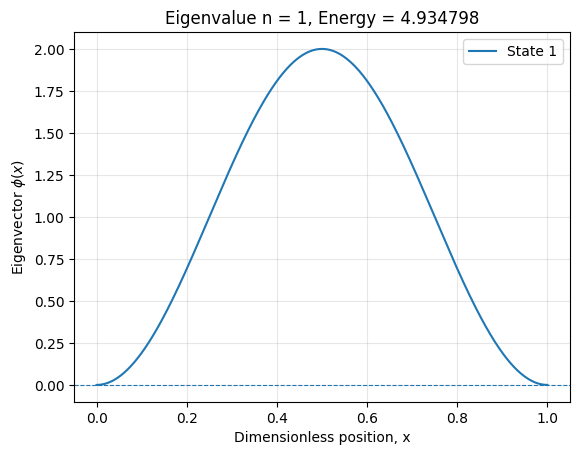

In [6]:
interior_points = 1000
potential_values = np.zeros(interior_points)

x, phi, energy = probability_distributuion(
    xi=0,
    xf=1,
    interior_points=interior_points,
    state_index=0,
    potential_values=potential_values
)

**Step Potential**

**Solution and plotting of Step potential**

In [36]:
def step_potential(x,x0,V0):
    potential_values = np.zeros(len(x))
    potential_values[x >= x0] = V0

    return potential_values

def solve_step_potential(xi,xf,interior_points,state_index,x0,v0):
  delta_x = (xf - xi)/(interior_points + 1)
  interior_grid = (xi + delta_x*np.arange(1,interior_points+1))

  potential_values = step_potential(interior_grid,x0,v0)

  if state_index < 0 or state_index >= interior_points:
    raise ValueError("state_index must lie between 0 and interior_points - 1.")
  if x0 > xf or x0 < xi:
     raise ValueError("x0 must lie between xi and xf")

  H = hamiltonian_matrix(delta_x,potential_values)

  eigenvalues,eigenvectors = np.linalg.eigh(H)

  phi_interior   = eigenvectors[:,state_index]
  energy_value   = eigenvalues[state_index]
  phi            = np.concatenate(([0.0],phi_interior,[0.0]))
  normalization  = np.sum(np.abs(phi)**2)*delta_x
  phi_normalized = phi/np.sqrt(normalization)
  full_grid      = np.concatenate(([xi],interior_grid,[xf]))
  quantum_number = state_index + 1
  check = np.sum(np.abs(phi_normalized)**2) * delta_x
  print("Normalization =", check)

  plt.plot(full_grid,phi_normalized,label=f"State {quantum_number}")
  plt.axhline(0,linewidth=0.8,linestyle="--")
  plt.axvline(x0,linewidth=1.0)
  plt.xlabel("Dimensionless position, x")
  plt.ylabel(r"Wavefunction $\phi(x)$")
  plt.title(f"Eigenvalue n = {quantum_number}, "f"Energy = {energy_value:.6f}")
  plt.grid(alpha=0.3)
  plt.legend()
  plt.show()

  return full_grid,phi_normalized,energy_value
    



Normalization = 1.0


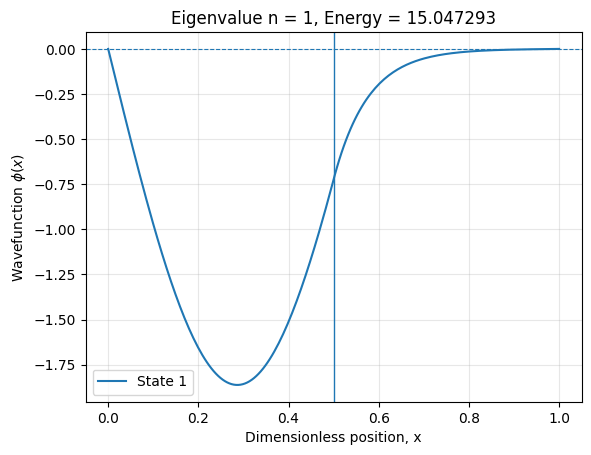

In [37]:
interior_points = 200
V0 = 100
x0 = 0.5
state_index = 0
full_grid,phi_normalized,energy_value = solve_step_potential(0,1,interior_points,state_index,x0,V0)